# Merge Observed Station Data

In [11]:
# 1. Standardize Observation CSVs
import glob
import pandas as pd
import numpy as np
import os
import warnings
warnings.simplefilter('ignore')

obs_dir = "data/observation/"
obs_files = glob.glob(os.path.join(obs_dir, "*.csv"))

all_obs_list = []

for f in obs_files:
    df = pd.read_csv(f)
    print(f"Loaded {os.path.basename(f)} with shape {df.shape}")
    
    # Needs to standardize format and units.
    df["SampleDate"] = pd.to_datetime(df["SampleDate"], errors="coerce")
    df = df.dropna(subset=["SampleDate"])
    
    # Force pure python float
    df["Result_Value"] = [float(x) if pd.notnull(x) else np.nan for x in pd.to_numeric(df["Result_Value"], errors="coerce")]
    df = df.dropna(subset=["Result_Value"])
    
    # remove negatives/non-detects
    df = df[df["Result_Value"] > 0]
    
    # Make StationID standard strings
    df["StationID"] = df["StationID"].astype(str).str.strip().str.lstrip('0')
    
    # Based on parameter name
    for param in ["TN_ugl"]:
        if param in df["Parameter"].values:
            df.loc[df["Parameter"] == param, "Result_Value"] = df.loc[df["Parameter"] == param, "Result_Value"] / 1000.0
         
    # Standardize parameter names
    df["Parameter"] = df["Parameter"].replace(
        {"TN_ugl": "TN", "TN_mgl": "TN"}
    )
    
    # Remove outliers (using general reasonable limits for TN in this region)
    # E.g. TN > 50 mg/L
    df = df[~((df["Parameter"] == "TN") & (df["Result_Value"] > 50))]
    
    # Drop duplicates
    df = df.drop_duplicates(subset=["StationID", "SampleDate", "Parameter"])
    
    # Append
    all_obs_list.append(df[["StationID", "SampleDate", "Parameter", "Result_Value"]])
    
obs_df = pd.concat(all_obs_list, ignore_index=True)
print(f"\nFinal standard obs dataset shape: {obs_df.shape}")
obs_df.head()

Loaded station_02296750_data.csv with shape (911, 21)
Loaded station_02297330_data.csv with shape (379, 21)
Loaded station_270318081593100_data.csv with shape (333, 21)
Loaded station_3556_data.csv with shape (582, 21)
Loaded station_PR14_data.csv with shape (677, 21)
Loaded station_PR18_data.csv with shape (1175, 21)

Final standard obs dataset shape: (2741, 4)


,StationID,SampleDate,Parameter,Result_Value
0,2296750,1939-10-31,TP_ugl,3500.0
1,2296750,1960-10-27,TP_ugl,10000.0
2,2296750,1960-12-02,TP_ugl,8900.0
3,2296750,1961-01-12,TP_ugl,8300.0
4,2296750,1961-03-06,TP_ugl,8400.0


In [12]:
# 2. Load the Arcadia WAM model output
model_file = "data/model/Station 02296750 (ARCADIA)_reach000084_83.csv"
model_df = pd.read_csv(model_file)

# Align dates to same format
model_df["SimDate"] = pd.to_datetime(model_df["SimDate"], format="mixed", errors="coerce")
model_df = model_df.dropna(subset=["SimDate"])
model_df = model_df.set_index("SimDate")

# We want TN columns
model_df = model_df[["Flow", "TN"]].dropna()
print(f"Arcadia WAM loaded, shape: {model_df.shape}")

# Create USGS flow dataset (Flow is in cubic ft/sec, but this is Arcadia model flow, which serves the same purpose)
flow_df = model_df[["Flow"]]
flow_df.head()

Arcadia WAM loaded, shape: (9132, 2)


,Flow
SimDate,
1999-01-01 00:00:00,0.00000
1999-01-01 12:00:00,0.00000
1999-01-02 12:00:00,0.01448
1999-01-03 12:00:00,6.37514
1999-01-04 12:00:00,25.51488


In [13]:
# 3. Merge All Data & Produce Timeline

# Merge datasets into one long format
obs_long = obs_df.set_index(["SampleDate", "StationID"])

# Station Timeline & Overlaps
stations = obs_df["StationID"].unique()
print(f"Found {len(stations)} unique stations: {stations}")

# Generate catalog of available data ranges per station
catalog = []
for st in stations:
    st_data = obs_df[obs_df["StationID"] == st]
    min_date = st_data["SampleDate"].min()
    max_date = st_data["SampleDate"].max()
    n_obs = len(st_data)
    catalog.append({
        "StationID": st,
        "Start_Date": min_date,
        "End_Date": max_date,
        "Total_Obs": n_obs
    })

catalog_df = pd.DataFrame(catalog)
print("\n--- Station Timeline Catalog ---")
print(catalog_df)

# Pairwise overlap catalog
print("\n--- Overlap Windows ---")
for i in range(len(stations)):
    for j in range(i+1, len(stations)):
        st1, st2 = stations[i], stations[j]
        data1 = obs_df[obs_df["StationID"] == st1]
        data2 = obs_df[obs_df["StationID"] == st2]
        
        # Merge on SampleDate & Parameter
        overlap = pd.merge(data1, data2, on=["SampleDate", "Parameter"], suffixes=('_st1', '_st2'))
        
        if len(overlap) > 0:
            min_ov = overlap["SampleDate"].min()
            max_ov = overlap["SampleDate"].max()
            print(f"{st1} & {st2}: {len(overlap)} overlapping records ({min_ov.date()} to {max_ov.date()})")
        else:
            print(f"{st1} & {st2}: 0 overlapping records")

Found 6 unique stations: <StringArray>
['2296750', '2297330', '270318081593100', '3556', 'PR14', 'PR18']
Length: 6, dtype: str

--- Station Timeline Catalog ---
         StationID Start_Date   End_Date  Total_Obs
0          2296750 1939-10-31 2004-09-29        628
1          2297330 1983-03-10 2000-06-27        118
2  270318081593100 1996-08-26 2000-06-27         94
3             3556 1998-10-08 2024-11-05        582
4             PR14 1996-08-26 2022-12-21        406
5             PR18 1996-08-26 2022-12-21        913

--- Overlap Windows ---
2296750 & 2297330: 9 overlapping records (1984-07-10 to 1998-03-24)
2296750 & 270318081593100: 5 overlapping records (1996-11-19 to 1998-03-24)
2296750 & 3556: 2 overlapping records (1999-08-11 to 1999-08-11)
2296750 & PR14: 9 overlapping records (1996-11-19 to 2002-11-26)
2296750 & PR18: 11 overlapping records (1996-11-19 to 2003-02-12)
2297330 & 270318081593100: 94 overlapping records (1996-08-26 to 2000-06-27)
2297330 & 3556: 0 overlapping rec

## Phase 2 - Normalize and Merge Observations

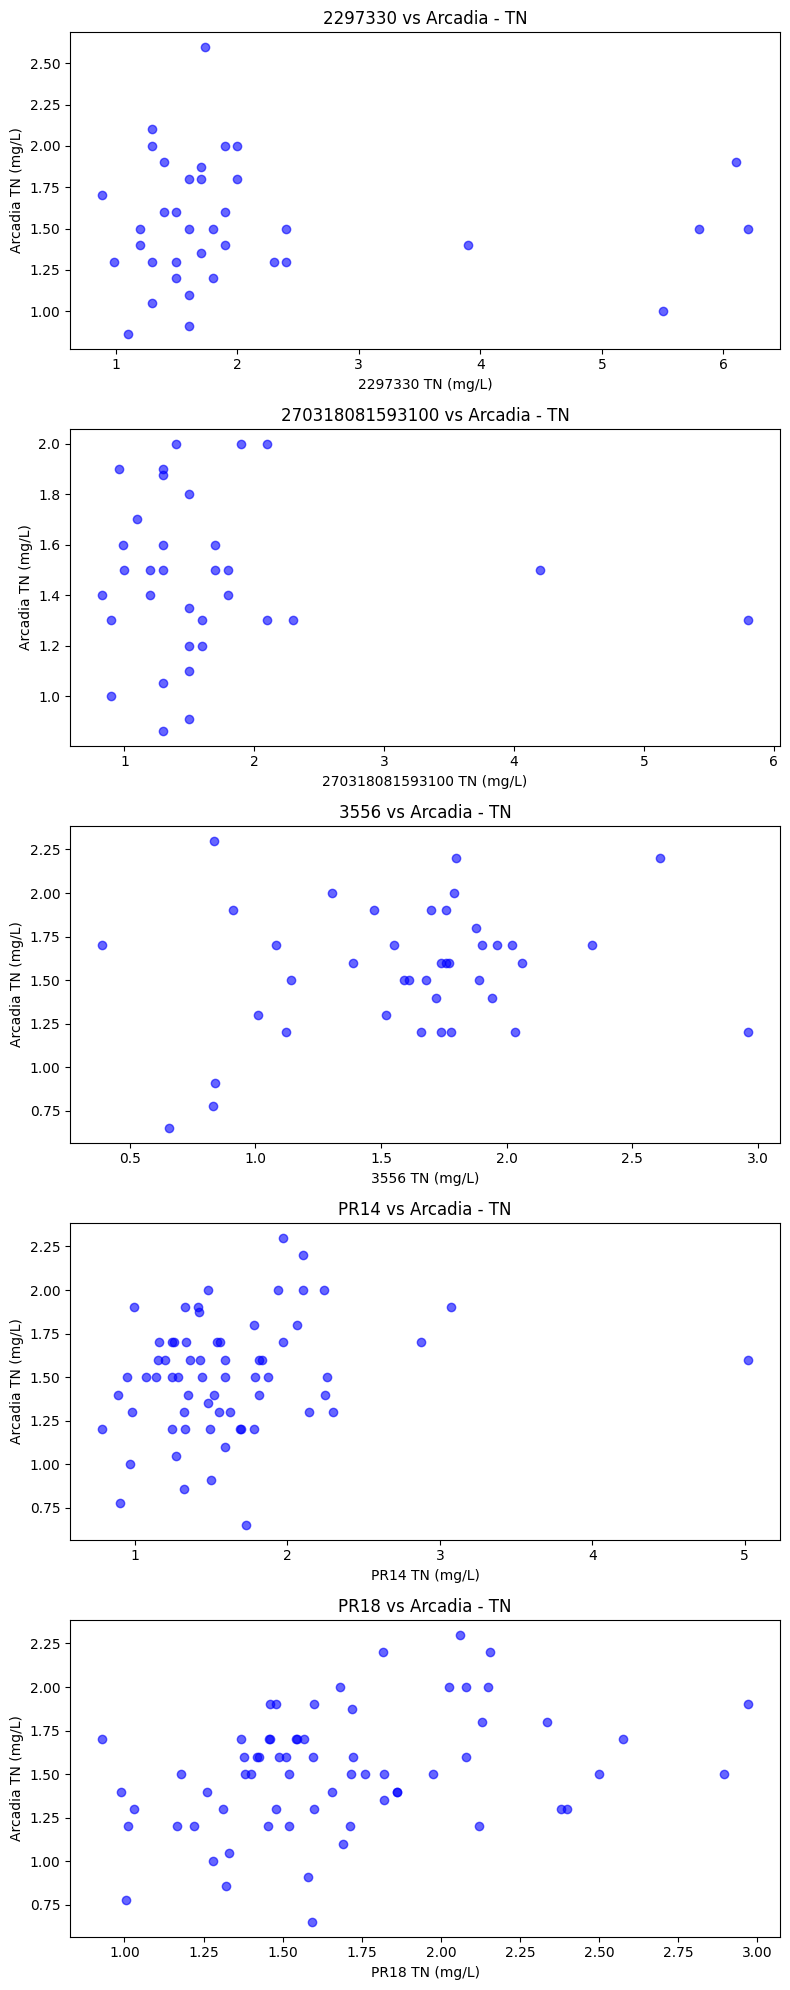


--- Validation Results (RMSE) - Monthly Relaxed Matches ---


,Station,Parameter,N_Overlap,RMSE_Baseline,RMSE_LR
0,2297330,TN,37,0.852292,0.335531
1,270318081593100,TN,33,0.510705,0.393302
2,3556,TN,40,0.617846,0.409611
3,PR14,TN,65,0.492784,0.347609
4,PR18,TN,66,0.549102,0.390657


In [14]:
# Since exact day matches produced very few pairs, we can use monthly means or wider temporal overlap windows
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

arcadia_id = "2296750"
stations = obs_df["StationID"].unique()
other_stations = [s for s in stations if s != arcadia_id]

arc_data_monthly = obs_df[obs_df["StationID"] == arcadia_id].set_index(["SampleDate", "Parameter"])["Result_Value"].unstack().resample('ME').mean()

station_models = {}
validation_results = []

fig, axes = plt.subplots(len(other_stations), 1, figsize=(8, 4*len(other_stations)))
if len(other_stations) == 1: axes = [axes]

for i, st in enumerate(other_stations):
    st_data_monthly = obs_df[obs_df["StationID"] == st].set_index(["SampleDate", "Parameter"])["Result_Value"].unstack().resample('ME').mean()
    
    paired = pd.merge(arc_data_monthly, st_data_monthly, left_index=True, right_index=True, suffixes=('_arc', '_st'))
    
    for j, param in enumerate(["TN"]):
        if f"{param}_arc" not in paired.columns or f"{param}_st" not in paired.columns:
            continue
            
        param_pair = paired[[f"{param}_arc", f"{param}_st"]].dropna()
        if len(param_pair) < 5:
            continue
            
        # Exploratory Scatter
        ax = axes[i]
        sc = ax.scatter(param_pair[f"{param}_st"], param_pair[f"{param}_arc"], alpha=0.6, color='blue')
        ax.set_title(f"{st} vs Arcadia - {param}")
        ax.set_xlabel(f"{st} {param} (mg/L)")
        ax.set_ylabel(f"Arcadia {param} (mg/L)")
            
        # Train-test split
        X = param_pair[[f"{param}_st"]]
        y = param_pair[f"{param}_arc"]
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
        
        y_st_train = X_train[f"{param}_st"]
        y_st_test = X_test[f"{param}_st"]
        
        # 1. Linear Regression
        lr = LinearRegression()
        lr.fit(y_st_train.values.reshape(-1, 1), y_train)
        pred_lr = lr.predict(y_st_test.values.reshape(-1, 1))
        rmse_lr = np.sqrt(mean_squared_error(y_test, pred_lr))
        
        # 2. Baseline
        rmse_base = np.sqrt(mean_squared_error(y_test, y_st_test))
        
        res = {
            "Station": st, "Parameter": param, "N_Overlap": len(param_pair),
            "RMSE_Baseline": rmse_base,
            "RMSE_LR": rmse_lr
        }
        validation_results.append(res)
        
        # Force Linear Regression method
        station_models[(st, param)] = {"method": "LR", "model": lr, "rmse": rmse_lr}

plt.tight_layout()
plt.show()

val_df = pd.DataFrame(validation_results)
print("\n--- Validation Results (RMSE) - Monthly Relaxed Matches ---")
display(val_df)

Unified Multi-Station Dataset Assembled!
Total Date-Parameter Unique Records: 1097


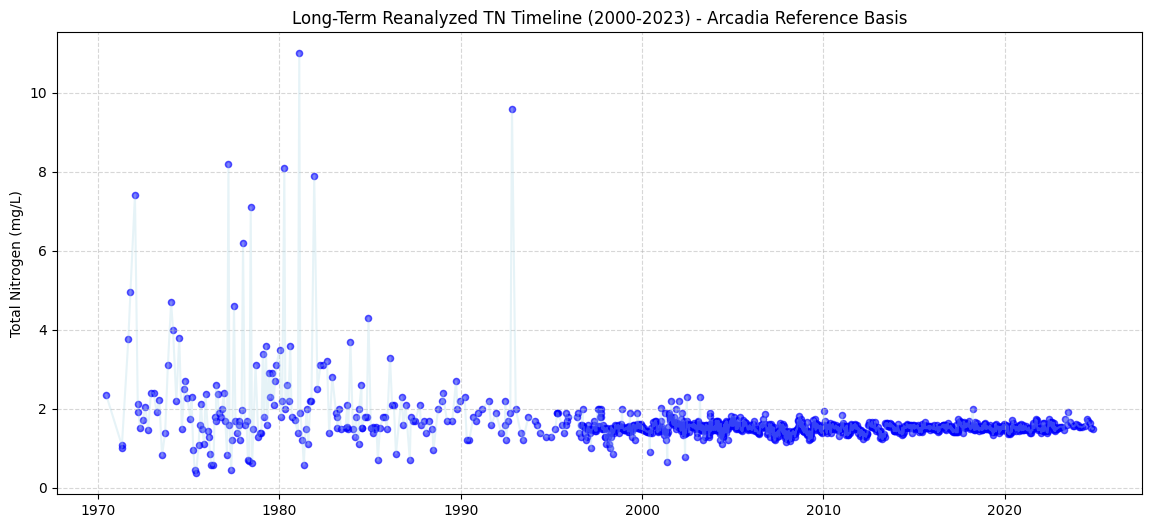

In [15]:
# 4. Phase 3: Transform and Stitch Best Normalized Pipeline 

transformed_records = []

# Baseline for Arcadia (self)
arcadia_full = obs_df[obs_df["StationID"] == arcadia_id].copy()
arcadia_full = arcadia_full[arcadia_full["Parameter"] == "TN"].copy() # ENFORCE strictly TN

arcadia_full["Normalized_Value"] = arcadia_full["Result_Value"]
arcadia_full["Method_Used"] = "Reference"
transformed_records.append(arcadia_full)

for st in other_stations:
    st_data = obs_df[(obs_df["StationID"] == st) & (obs_df["Parameter"] == "TN")].copy() # ENFORCE strictly TN
    
    st_data["Normalized_Value"] = np.nan
    st_data["Method_Used"] = "Baseline"
    
    for param in ["TN"]:
        method_info = station_models.get((st, param))
        mask = st_data["Parameter"] == param
        
        if method_info is None or len(st_data[mask]) == 0:
            st_data.loc[mask, "Normalized_Value"] = st_data.loc[mask, "Result_Value"]
            st_data.loc[mask, "Method_Used"] = "None_Found"
            continue
            
        m_name = method_info["method"]
        m_obj = method_info["model"]
        
        orig_vals = st_data.loc[mask, "Result_Value"].values
        
        if m_name == "LR":
            norm_vals = m_obj.predict(orig_vals.reshape(-1, 1))
        else:
            norm_vals = orig_vals
            
        norm_vals = np.clip(norm_vals, a_min=0.01, a_max=st_data.loc[mask, "Result_Value"].max() * 1.5)
        
        st_data.loc[mask, "Normalized_Value"] = norm_vals
        st_data.loc[mask, "Method_Used"] = m_name

    transformed_records.append(st_data)

final_reanalysis_df = pd.concat(transformed_records, ignore_index=True)

# Important: groupby resets indices if applying multiple columns without re-assigning proper indices
def prioritize_station_values(group):
    if len(group) == 0:
        return None
    arc_obs = group[group["StationID"] == arcadia_id]
    if len(arc_obs) > 0:
        return arc_obs.iloc[0]
    
    mean_val = group["Normalized_Value"].mean()
    rep_row = group.iloc[0].copy()
    rep_row["StationID"] = "Merged_Average"
    rep_row["Normalized_Value"] = mean_val
    rep_row["Method_Used"] = "Averaged_Transform"
    return rep_row

unified_timeline = final_reanalysis_df.groupby(["SampleDate", "Parameter"], as_index=False).apply(prioritize_station_values).reset_index(drop=True)

print("Unified Multi-Station Dataset Assembled!")
print(f"Total Date-Parameter Unique Records: {len(unified_timeline)}")

import matplotlib.dates as mdates

fig, ax = plt.subplots(figsize=(14, 6))
tn_timeline = unified_timeline[unified_timeline["Parameter"] == "TN"].sort_values("SampleDate")

ax.scatter(tn_timeline["SampleDate"], tn_timeline["Normalized_Value"], alpha=0.6, color='blue', s=20)
ax.plot(tn_timeline["SampleDate"], tn_timeline["Normalized_Value"], color='lightblue', alpha=0.3)

ax.set_title("Long-Term Reanalyzed TN Timeline (2000-2023) - Arcadia Reference Basis")
ax.set_ylabel("Total Nitrogen (mg/L)")
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.grid(True, linestyle="--", alpha=0.5)

plt.show()

In [16]:
# Quick Validation check: Why was standardization needed?
# Comparing Reference to Non-normalized values across overlapping stations
from sklearn.metrics import mean_squared_error, mean_absolute_error

print("--- Comparison of Overlapping Records: Raw vs Optimized Normalized ---")
for st in other_stations:
    st_data = obs_df[obs_df["StationID"] == st].set_index(["SampleDate", "Parameter"])["Result_Value"].unstack().resample('ME').mean()
    arc_data_monthly = obs_df[obs_df["StationID"] == arcadia_id].set_index(["SampleDate", "Parameter"])["Result_Value"].unstack().resample('ME').mean()
    
    paired = pd.merge(arc_data_monthly, st_data, left_index=True, right_index=True, suffixes=('_arc', '_st'))
    
    for param in ["TN"]:
        if f"{param}_arc" not in paired.columns or f"{param}_st" not in paired.columns:
            continue
            
        param_pair = paired[[f"{param}_arc", f"{param}_st"]].dropna()
        if len(param_pair) < 5: continue
            
        y_true = param_pair[f"{param}_arc"]
        y_raw = param_pair[f"{param}_st"]
        
        m_info = station_models.get((st, param))
        if m_info is None: continue
            
        m_name = m_info["method"]
        m_obj = m_info["model"]
        
        if m_name == "LR":
            y_norm = m_obj.predict(y_raw.values.reshape(-1, 1))
        else:
            y_norm = y_raw.values
            
        raw_rmse = np.sqrt(mean_squared_error(y_true, y_raw))
        norm_rmse = np.sqrt(mean_squared_error(y_true, y_norm))
        
        print(f"Station {st} {param} | Raw RMSE: {raw_rmse:.3f} -> Optimized ({m_name}) RMSE: {norm_rmse:.3f}")

--- Comparison of Overlapping Records: Raw vs Optimized Normalized ---
Station 2297330 TN | Raw RMSE: 1.584 -> Optimized (LR) RMSE: 0.363
Station 270318081593100 TN | Raw RMSE: 1.021 -> Optimized (LR) RMSE: 0.308
Station 3556 TN | Raw RMSE: 0.566 -> Optimized (LR) RMSE: 0.358
Station PR14 TN | Raw RMSE: 0.631 -> Optimized (LR) RMSE: 0.322
Station PR18 TN | Raw RMSE: 0.474 -> Optimized (LR) RMSE: 0.317


In [17]:
# Filter the final timeline to only include dates from 2000 to 2023
unified_timeline_filtered = unified_timeline[
    (unified_timeline["SampleDate"] >= "2000-01-01") & 
    (unified_timeline["SampleDate"] <= "2023-12-31")
]

# Export
unified_timeline_filtered.to_csv("Arcadia_Unified_TN_Reanalysis_2000_2023.csv", index=False)
unified_timeline_filtered.head()

,SampleDate,Parameter,StationID,Result_Value,Normalized_Value,Method_Used
300,2000-01-05,TN,Merged_Average,1.56,1.561020,Averaged_Transform
301,2000-01-18,TN,Merged_Average,1.30,1.469676,Averaged_Transform
302,2000-02-09,TN,Merged_Average,1.34,1.510105,Averaged_Transform
303,2000-02-15,TN,Merged_Average,1.10,1.466465,Averaged_Transform
304,2000-03-08,TN,Merged_Average,1.09,1.452246,Averaged_Transform


In [18]:
# 6. Validation using Nearest-Neighbor Matching (±15 days)
print("--- Validation Results: Nearest-Neighbor (±15 days) vs Monthly Averaged ---")

# We need the raw unaggregated data for Arcadia
arc_raw = obs_df[obs_df["StationID"] == arcadia_id].sort_values("SampleDate")

nn_validation_results = []

for st in other_stations:
    st_raw = obs_df[obs_df["StationID"] == st].sort_values("SampleDate")
    
    for param in ["TN"]:
        # Filter by parameter
        arc_p = arc_raw[arc_raw["Parameter"] == param].dropna(subset=["Result_Value"])
        st_p = st_raw[st_raw["Parameter"] == param].dropna(subset=["Result_Value"])
        
        if len(arc_p) == 0 or len(st_p) == 0:
            continue
            
        # Perform merge_asof to find closest Arcadia record within ±15 days
        paired_nn = pd.merge_asof(
            st_p, 
            arc_p, 
            on="SampleDate", 
            direction="nearest", 
            tolerance=pd.Timedelta(days=15),
            suffixes=('_st', '_arc')
        ).dropna(subset=["Result_Value_arc"])
        
        if len(paired_nn) < 5:
            continue
            
        y_true = paired_nn["Result_Value_arc"].values
        y_raw = paired_nn["Result_Value_st"].values
        
        m_info = station_models.get((st, param))
        if m_info is None:
            continue
            
        m_name = m_info["method"]
        m_obj = m_info["model"]
        
        if m_name == "LR":
            y_norm = m_obj.predict(y_raw.reshape(-1, 1))
        else:
            y_norm = y_raw
            
        raw_rmse_nn = np.sqrt(mean_squared_error(y_true, y_raw))
        norm_rmse_nn = np.sqrt(mean_squared_error(y_true, y_norm))
        
        # Get the monthly RMSE from previously calculated validation_results if available
        monthly_norm_rmse = None
        for res in validation_results:
            if res["Station"] == st and res["Parameter"] == param:
                monthly_norm_rmse = res[f"RMSE_{m_name}"]
                break
                
        monthly_str = f"{monthly_norm_rmse:.3f}" if monthly_norm_rmse is not None else "N/A"
        
        nn_validation_results.append({
            "Station": st, "Parameter": param, "N_Pairs (±15d)": len(paired_nn),
            "Method": m_name,
            "NN_Raw_RMSE": raw_rmse_nn,
            "NN_Norm_RMSE": norm_rmse_nn,
            "Monthly_Norm_RMSE": monthly_norm_rmse
        })
        
        print(f"Station {st} {param} | Pairs: {len(paired_nn)} | Method: {m_name} | "
              f"NN Raw RMSE: {raw_rmse_nn:.3f} -> NN Norm RMSE: {norm_rmse_nn:.3f} "
              f"(vs Monthly: {monthly_str})")
              
nn_val_df = pd.DataFrame(nn_validation_results)
display(nn_val_df)

--- Validation Results: Nearest-Neighbor (±15 days) vs Monthly Averaged ---
Station 2297330 TN | Pairs: 40 | Method: LR | NN Raw RMSE: 1.419 -> NN Norm RMSE: 0.431 (vs Monthly: 0.336)
Station 270318081593100 TN | Pairs: 33 | Method: LR | NN Raw RMSE: 1.007 -> NN Norm RMSE: 0.319 (vs Monthly: 0.393)
Station 3556 TN | Pairs: 38 | Method: LR | NN Raw RMSE: 0.506 -> NN Norm RMSE: 0.390 (vs Monthly: 0.410)
Station PR14 TN | Pairs: 65 | Method: LR | NN Raw RMSE: 0.575 -> NN Norm RMSE: 0.320 (vs Monthly: 0.348)
Station PR18 TN | Pairs: 91 | Method: LR | NN Raw RMSE: 0.417 -> NN Norm RMSE: 0.305 (vs Monthly: 0.391)


,Station,Parameter,N_Pairs (±15d),Method,NN_Raw_RMSE,NN_Norm_RMSE,Monthly_Norm_RMSE
0,2297330,TN,40,LR,1.419178,0.431397,0.335531
1,270318081593100,TN,33,LR,1.006676,0.319298,0.393302
2,3556,TN,38,LR,0.505658,0.389903,0.409611
3,PR14,TN,65,LR,0.575263,0.319801,0.347609
4,PR18,TN,91,LR,0.417134,0.304542,0.390657


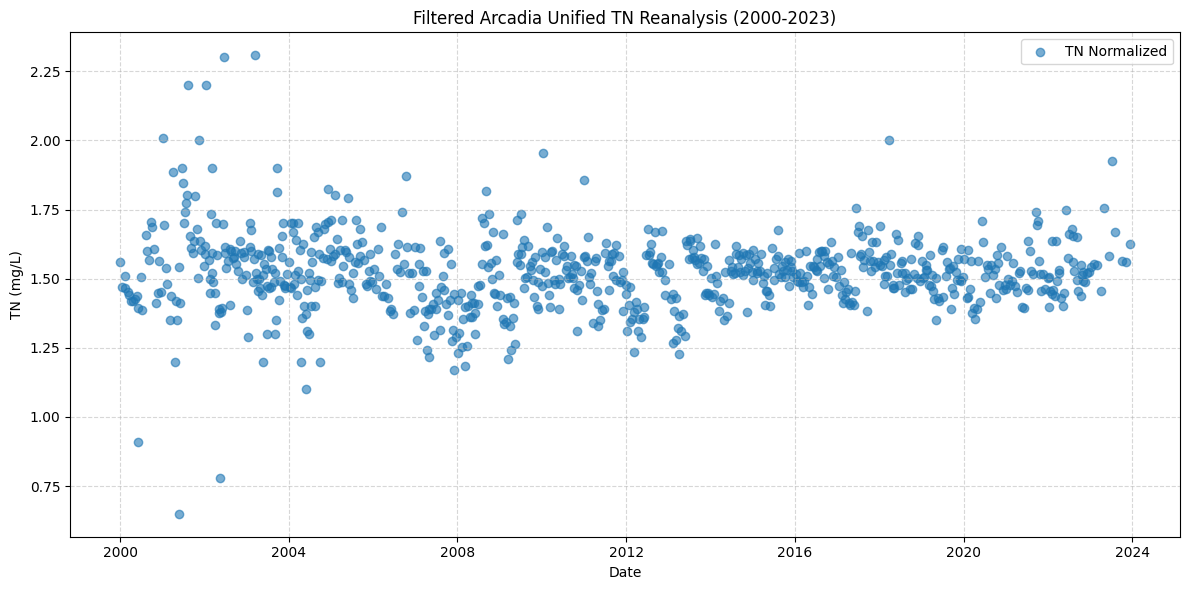

In [19]:
import matplotlib.pyplot as plt
import pandas as pd

# Load the exported CSV
plot_df = pd.read_csv("Arcadia_Unified_TN_Reanalysis_2000_2023.csv")
plot_df["SampleDate"] = pd.to_datetime(plot_df["SampleDate"])

plt.figure(figsize=(12, 6))
plt.scatter(plot_df["SampleDate"], plot_df["Normalized_Value"], marker='o', alpha=0.6, label="TN Normalized")
plt.title("Filtered Arcadia Unified TN Reanalysis (2000-2023)")
plt.xlabel("Date")
plt.ylabel("TN (mg/L)")
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

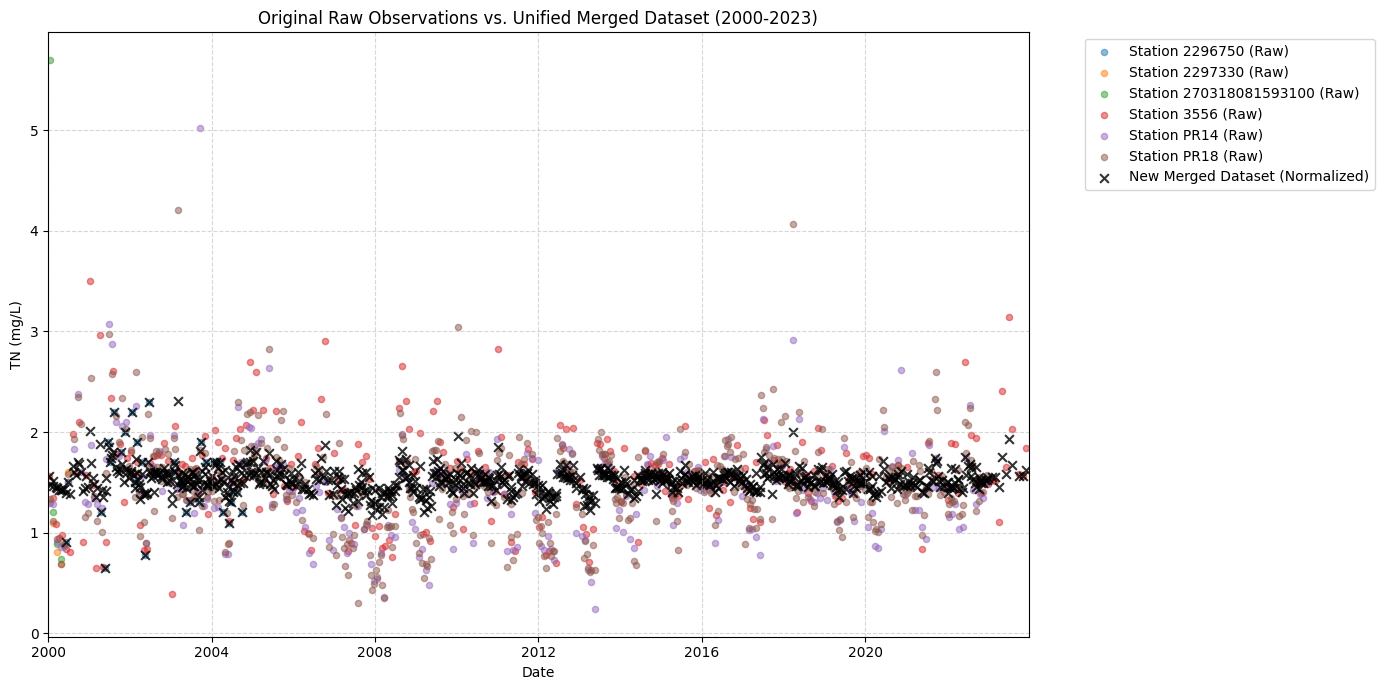

In [21]:
import matplotlib.pyplot as plt
import pandas as pd

# Load the exported CSV
merged_df = pd.read_csv("Arcadia_Unified_TN_Reanalysis_2000_2023.csv")
merged_df["SampleDate"] = pd.to_datetime(merged_df["SampleDate"])

plt.figure(figsize=(14, 7))

# Plot original observation data by station
# (obs_df should still be in memory from previous cells)
for st in obs_df["StationID"].unique():
    st_data = obs_df[(obs_df["StationID"] == st) & (obs_df["Parameter"] == "TN")].copy()
    
    # Cap original observations to the 2000-2023 interval
    st_data = st_data[(st_data["SampleDate"] >= "2000-01-01") & (st_data["SampleDate"] <= "2023-12-31")]
    
    if len(st_data) > 0:
        plt.scatter(st_data["SampleDate"], st_data["Result_Value"], alpha=0.5, label=f"Station {st} (Raw)", s=20)

# Plot the new merged dataset in black
plt.scatter(merged_df["SampleDate"], merged_df["Normalized_Value"], 
            color='black', marker='x', alpha=0.8, label="New Merged Dataset (Normalized)", s=40)

plt.title("Original Raw Observations vs. Unified Merged Dataset (2000-2023)")
plt.xlabel("Date")
plt.ylabel("TN (mg/L)")

plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xlim(pd.Timestamp("2000-01-01"), pd.Timestamp("2023-12-31"))
plt.tight_layout()
plt.show()